# Notebook — Modelisation

Ce notebook présente une démarche complète sur le jeu de données Home Credit Default Risk :Chargement et préparation des données : 

Modélisation & Optimisation : Entraînement de l'algorithme et recherche d'hyperparamètres (GridSearchCV) ;  Évaluation globale & Optimisation métier : Calcul des métriques clés (ROC-AUC ) sur le jeu de test
Recherche du seuil de décision : Détermination du seuil financier optimal (0.18) basé sur la minimisation des coûts réels plutôt que sur le seuil standard de 0.5
Analyse des erreurs & Impact financier : Quantifications des faux négatifs et faux positifs 
Synthèse et perspectives MLOps : Recommandations pour la validation des hypothèses de coûts avec le métier et l'industrialisation du pipeline de ré-entraînement.



## Installation et import des bibliothèques + MLFLow

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# imputer for handling missing values
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# f2/3 scores
from sklearn.metrics import fbeta_score  # Calcul du score F-beta pour évaluer la performance du modèle
# --- MÉTRIQUES D'ÉVALUATION PERSONNALISÉES : la fonction de score métier (F2 / F3)---
def business_fbeta_score(y_true, y_pred, beta=2):
    """
    Calcule le score F-beta.
    beta=2 ou beta=3 privilégie le rappel par rapport à la précision,
    adapté au coût d'un faux bon client (10x plus élevé).
    """
    return fbeta_score(y_true, y_pred, beta=beta)

from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.lightgbm



"""import warnings
warnings.filterwarnings("ignore")"""


2026/09/06 11:25:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


'import warnings\nwarnings.filterwarnings("ignore")'

In [6]:
mlflow.autolog()
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("MLflow_Projet1_Home_Credit")

2026/09/06 11:28:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1788686679136, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1788686679136, lifecycle_stage='active', name='MLflow_Projet1_Home_Credit', tags={}, trace_location=None, workspace='default'>

## Chargement des données

In [7]:
df_train = pd.read_parquet("./input/train_engineered.parquet")
df_test = pd.read_parquet("./input/test_engineered.parquet")

print("Dimensions du train :", df_train.shape)
print("Dimensions du test  :", df_test.shape)

df_train.head()

Dimensions du train : (307511, 239)
Dimensions du test  : (48744, 238)


,SK_ID_CURR,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,...,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,TARGET
0,0.000000,0.0,0.0,1.0,0.0,0.001512,0.090287,0.090032,0.077441,0.256321,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,0.000003,0.0,0.0,0.0,0.0,0.002089,0.311736,0.132924,0.271605,0.045016,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.000006,1.0,1.0,1.0,0.0,0.000358,0.022472,0.020025,0.023569,0.134897,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.000011,0.0,0.0,1.0,0.0,0.000935,0.066837,0.109477,0.063973,0.107023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.000014,0.0,0.0,1.0,0.0,0.000819,0.116854,0.078975,0.117845,0.392880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Séparation features / cible

In [8]:
X_train = df_train.drop(columns="TARGET").copy()
y_train = df_train["TARGET"].copy()

print("Nombre de variables explicatives :", X_train.shape[1])
print("Nombre d'observations :", X_train.shape[0])

Nombre de variables explicatives : 238
Nombre d'observations : 307511


## Création du modèle Regression logistique (baseline)

In [9]:
# Instancie le modèle de Régression Logistique avec un paramètre de régularisation C égal à 0.0001 (forte régularisation L2 par défaut pour limiter le surapprentissage)
log_reg = LogisticRegression(C = 0.0001)

# Entraîne l'algorithme de régression logistique en lui passant les caractéristiques (X_train) et la variable cible (y_train)
log_reg.fit(X_train, y_train)

# Affiche un message de confirmation dans la console une fois l'entraînement du modèle terminé
print(" Modèle Logistic Regression entraîné.")

2026/09/06 11:28:39 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e840a0946bbe4241a30dd4a11a0535c1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 11:30:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

🏃 View run rare-sow-403 at: http://localhost:5000/#/experiments/2/runs/e840a0946bbe4241a30dd4a11a0535c1
🧪 View experiment at: http://localhost:5000/#/experiments/2
 Modèle Logistic Regression entraîné.


## Regression logistique - Faire les prédictions 

In [10]:
# Make predictions 
# Make sure to select the second column only
# Classes prédites (0 ou 1) et Probabilités
log_reg_pred_y = log_reg.predict(df_test)
#print("Classes prédites (0 ou 1) : ", log_reg_pred_y[:10])
log_reg_pred = log_reg.predict_proba(df_test)[:, 1]

# Submission dataframe
submit = df_test[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()   


,SK_ID_CURR,TARGET
0,-0.000003,0.065361
1,0.000008,0.118065
2,0.000031,0.068434
3,0.000073,0.070807
4,0.000101,0.118257


## Regression logistique - Évaluer le modèle sur les données Train

In [11]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

def evaluate_model(y_true, y_pred, y_proba):
    return {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

# 2. Découpage des données (C'est cette étape qui crée y_valid !)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# changer l'appel de X_train en faisant des copy()
# appeler X et Y pas besoin de x_train

# 3. Entraînement sur le sous-ensemble X_train
log_reg = LogisticRegression(C=0.0001, max_iter=1000)
log_reg.fit(X_train, y_train)

# 4. Prédictions sur la validation (X_valid)
y_pred = log_reg.predict(X_valid)
y_pred_proba = log_reg.predict_proba(X_valid)[:, 1]

# 5. Évaluation
metrics_all = evaluate_model(y_valid, y_pred, y_pred_proba)
print("Métriques de validation :", metrics_all)

metrics_all

for metric, score in metrics_all.items():
    print(f"{metric:<10}: {score:.4f}")

roc_auc = metrics_all["ROC-AUC"]

2026/09/06 11:47:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5b96eb13d5664bf28b8776d9088b44a0', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 11:48:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

🏃 View run serious-bird-13 at: http://localhost:5000/#/experiments/2/runs/5b96eb13d5664bf28b8776d9088b44a0
🧪 View experiment at: http://localhost:5000/#/experiments/2
Métriques de validation : {'ROC-AUC': 0.6869602908925925, 'Accuracy': 0.9192722306228964, 'Precision': 0.0, 'Recall': 0.0, 'F1-score': 0.0}
ROC-AUC   : 0.6870
Accuracy  : 0.9193
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


## RANDOM FOREST

In [12]:
# Instancie le classifieur Random Forest en configurant ses hyperparamètres de base n_estimators = 100 (Nombre d'arbres), random_state = 50 (Graine d'aléatoire)
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

# Entraîne la forêt d'arbres sur les données d'apprentissage (variables X et cibles y)
random_forest.fit(X_train, y_train) 

# Calcule les probabilités de la classe 1 (positive) pour chaque échantillon du jeu de test
predictions = random_forest.predict_proba(df_test)[:, 1]

2026/09/06 11:50:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1d0a0c91a51b490cbe587a44b2795cda', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   43.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
2026/09/06 11:52:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' for

🏃 View run enthused-finch-115 at: http://localhost:5000/#/experiments/2/runs/1d0a0c91a51b490cbe587a44b2795cda
🧪 View experiment at: http://localhost:5000/#/experiments/2


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


### RANDOM FOREST - Calcul ROC AUC - validation croisée

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(random_forest, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"ROC-AUC moyen (5-fold CV) : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

ROC-AUC moyen (5-fold CV) : 0.7076 (+/- 0.0048)


### LightGBM

In [15]:
# --- IMPORTS DES BIBLIOTHÈQUES ---
import lightgbm as lgb  # Algorithme d'arbres de décision boostés (Gradient Boosting)
from sklearn.model_selection import KFold  # Générateur de plis pour la validation croisée
from sklearn.metrics import roc_auc_score  # Calcul de la métrique AUC (Area Under Curve)
import numpy as np  # Calcul numérique et manipulation de tableaux
import gc  # Garbage Collector pour libérer la mémoire RAM inutilisée

# --- DÉFINITION DE LA FONCTION PRINCIPALE ---
def model_lightgbm(features, test_features, labels, n_folds=5):
    """
    Entraîne un LightGBM en validation croisée et retourne :
    - les prédictions sur le jeu de test
    - l'importance des variables
    - les scores ROC-AUC train/valid par fold
    """
    # Récupère les noms des colonnes si les données sont dans un DataFrame Pandas
    feature_names = list(features.columns) if hasattr(features, "columns") else None
    
    # Convertit les données d'entraînement et de test en tableaux NumPy pour plus de rapidité
    features = np.array(features)
    test_features = np.array(test_features)

    # Configure la validation croisée K-Fold : 5 plis (par défaut), données mélangées, graine fixée à 50
    k_fold = KFold(n_splits=n_folds, shuffle=True, random_state=50)

    # Initialise un tableau de zéros pour accumuler l'importance moyenne de chaque variable
    feature_importance_values = np.zeros(features.shape[1])
    
    # Initialise un tableau de zéros pour accumuler les prédictions moyennes sur le jeu de test
    test_predictions = np.zeros(test_features.shape[0])
    
    # Initialise un tableau pour stocker les prédictions "Out-Of-Fold" (OOF) de l'ensemble d'entraînement
    out_of_fold = np.zeros(features.shape[0])
    
    # Listes pour conserver les scores AUC d'entraînement et de validation pour chaque pli
    valid_scores, train_scores = [], []

    # --- BOUCLE SUR CHAQUE PLI (FOLD) DE LA VALIDATION CROISÉE ---
    for train_indices, valid_indices in k_fold.split(features):
        
        # Extrait les données et cibles d'entraînement spécifiques au pli courant
        train_features, train_labels = features[train_indices], labels.iloc[train_indices]
        
        # Extrait les données et cibles de validation spécifiques au pli courant
        valid_features, valid_labels = features[valid_indices], labels.iloc[valid_indices]

        # Instancie le classifieur LightGBM avec ses hyperparamètres
        lgb_model = lgb.LGBMClassifier(
            n_estimators=10000,        # Nombre maximal d'arbres à construire
            objective='binary',        # Tâche de classification binaire (0 ou 1)
            class_weight='balanced',   # Compense automatiquement le déséquilibre des classes
            learning_rate=0.05,        # Taux d'apprentissage appliqué à chaque arbre
            reg_alpha=0.1,             # Régularisation L1 (Lasso) pour éviter le surapprentissage
            reg_lambda=0.1,            # Régularisation L2 (Ridge) pour éviter le surapprentissage
            subsample=0.8,             # Échantillonne 80% des lignes pour chaque arbre
            n_jobs=-1,                 # Utilise tous les cœurs CPU disponibles
            random_state=50            # Graine aléatoire pour garantir la reproductibilité
        )

        # Lance l'entraînement du modèle pour le pli courant
        lgb_model.fit(
            train_features, train_labels,
            eval_metric='auc',  # Suivi de la métrique AUC sur les jeux d'évaluation
            eval_set=[(valid_features, valid_labels), (train_features, train_labels)],  # Données à évaluer
            eval_names=['valid', 'train'],  # Noms associés aux ensembles d'évaluation
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]  # Arrêt si pas de progrès sur valid en 100 tours
        )

        # Récupère le numéro de la meilleure itération (l'arbre où le score de validation était maximal)
        best_iteration = lgb_model.best_iteration_

        # Ajoute l'importance des variables du pli courant au total (divisée par n_splits pour faire la moyenne)
        feature_importance_values += lgb_model.feature_importances_ / k_fold.n_splits
        
        # Prédit les probabilités de la classe 1 sur le jeu de test et accumule la moyenne pondérée (1/n_splits)
        test_predictions += lgb_model.predict_proba(test_features, num_iteration=best_iteration)[:, 1] / k_fold.n_splits
        
        # Enregistre la prédiction de la classe 1 sur l'échantillon de validation dans le tableau Out-Of-Fold
        out_of_fold[valid_indices] = lgb_model.predict_proba(valid_features, num_iteration=best_iteration)[:, 1]

        # Enregistre les meilleurs scores AUC obtenus sur la validation et l'entraînement pour ce pli
        valid_scores.append(lgb_model.best_score_['valid']['auc'])
        train_scores.append(lgb_model.best_score_['train']['auc'])

        # --- NETTOYAGE DE LA MÉMOIRE RAM ---
        gc.enable()  # Active le Garbage Collector
        del lgb_model, train_features, valid_features  # Supprime les objets volumineux inutiles
        gc.collect()  # Force la libération de la RAM

    # --- CALCUL ET ASSEMBLAGE DES MÉTRIQUES GLOBALES ---
    # Calcule l'AUC global sur l'ensemble des prédictions hors-pli (out-of-fold)
    valid_auc = roc_auc_score(labels, out_of_fold)
    valid_scores.append(valid_auc)  # Ajoute le score global à la fin de la liste des scores de validation
    train_scores.append(np.mean(train_scores))  # Ajoute la moyenne des scores d'entraînement à la fin

    # Construit un DataFrame récapitulatif des scores par fold et du score global
    metrics = pd.DataFrame({
        'fold': list(range(n_folds)) + ['overall'],
        'train': train_scores,
        'valid': valid_scores
    })

    # Construit un DataFrame récapitulatif de l'importance moyenne des variables
    feature_importances = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance_values
    })

    # Renvoie les prédictions finales de test, l'importance des variables et le tableau de métriques
    return test_predictions, feature_importances, metrics


# --- EXÉCUTION DU MODÈLE ---
# Lance la validation croisée avec les DataFrames d'entraînement et de test
test_predictions, fi, metrics = model_lightgbm(X_train, df_test[X_train.columns], y_train)

# Affiche le tableau récapitulatif des performances AUC par fold et globale
print(metrics)

# --- GÉNÉRATION DU FICHIER DE SOUMISSION ---
# Crée un DataFrame Pandas contenant l'identifiant des clients et leurs probabilités prédites
submission = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET': test_predictions
})

# Exporte les résultats au format CSV prêt pour soumission (sans inclure l'index Pandas)
submission.to_csv('./input/submission_lgbm.csv', index=False)

2026/09/06 12:07:26 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/09/06 12:07:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2f426916876f4487b38419de8b60a5ac', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15910, number of negative: 180896
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11613
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 229
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


2026/09/06 12:07:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run illustrious-gull-760 at: http://localhost:5000/#/experiments/2/runs/2f426916876f4487b38419de8b60a5ac
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 12:08:09 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'beeaa7fa171d401b9114e70f11af1cd4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

🏃 View run caring-pug-78 at: http://localhost:5000/#/experiments/2/runs/67ef240fedfa4a33bded10d7825f5159
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 12:10:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'df04bfacfaed401ea0448dcd01715970', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15880, number of negative: 180927
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.150888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11677
[LightGBM] [Info] Number of data points in the train set: 196807, number of used features: 229
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/06 12:10:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run thoughtful-steed-211 at: http://localhost:5000/#/experiments/2/runs/df04bfacfaed401ea0448dcd01715970
🧪 View experiment at: http://localhost:5000/#/experiments/2
      fold     train     valid
0        0  0.799813  0.758433
1        1  0.813777  0.761420
2        2  0.815741  0.763361
3        3  0.804959  0.751381
4        4  0.803606  0.748906
5  overall  0.807579  0.756720


## TRAITEMENT DU DÉSÉQUILIBRE (PONDÉRATION, SMOTE)

On utilise le jeu de données complet (`X_full`, `y_full`), avant tout split, pour que toutes les comparaisons ci-dessous portent sur les mêmes données.

In [17]:
# TRAITEMENT DU DÉSÉQUILIBRE (PONDÉRATION, SMOTE)
import numpy as np

# Jeu de données complet (indépendant du split fait section 13)
X_full = df_train.drop(columns='TARGET').copy()
y_full = df_train['TARGET'].copy()

print('Répartition de TARGET :')
print(y_full.value_counts(normalize=True).rename('proportion'))

# Deux stratégies de traitement du déséquilibre :
# 1) pondération des classes (class_weight='balanced') : pénalise davantage les erreurs sur la classe minoritaire
# 2) SMOTE : sur-échantillonnage synthétique de la classe minoritaire (à appliquer UNIQUEMENT sur le train de chaque fold)
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


Répartition de TARGET :
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


## COMPARAISON RIGOUREUSE DES MODÈLES (VALIDATION CROISÉE)

 Les trois modèles (Logistic Regression, Random Forest, LightGBM) sont évalués sur les mêmes folds stratifiés, avec et sans traitement du déséquilibre, et comparés sur des métriques adaptées à un problème déséquilibré (ROC-AUC, PR-AUC, F1, precision, recall).

In [18]:
# VALIDATION CROISÉE + MÉTRIQUES ADAPTÉES AU DÉSÉQUILIBRE + COMPARAISON RIGOUREUSE DES MODÈLES
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

def evaluate_model(model_name, model_builder, X, y, n_folds=5, use_smote=False):
    """Évalue un modèle en validation croisée stratifiée, avec ou sans SMOTE."""
    X = np.array(X)
    y = np.array(y)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=50)

    scores = {'roc_auc': [], 'pr_auc': [], 'f1': [], 'f2': [], 'f3': [], 'precision': [], 'recall': []}

    for train_idx, valid_idx in skf.split(X, y):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_val, y_val = X[valid_idx], y[valid_idx]

        if use_smote:
            X_tr, y_tr = SMOTE(random_state=50).fit_resample(X_tr, y_tr)

        model = model_builder()
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_val)[:, 1]
        preds = (proba >= 0.5).astype(int)

        scores['roc_auc'].append(roc_auc_score(y_val, proba))
        scores['pr_auc'].append(average_precision_score(y_val, proba))
        scores['f1'].append(f1_score(y_val, preds, zero_division=0))
        scores['f2'].append(business_fbeta_score(y_val, preds, beta=2))
        scores['f3'].append(business_fbeta_score(y_val, preds, beta=3))
        scores['precision'].append(precision_score(y_val, preds, zero_division=0))
        scores['recall'].append(recall_score(y_val, preds, zero_division=0))

    return {'model': model_name, 'use_smote': use_smote, **{k: np.mean(v) for k, v in scores.items()}}


models_to_compare = [
    ("Logistic Regression (class_weight)",
     lambda: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=50), False),
    ("Logistic Regression (SMOTE)",
     lambda: LogisticRegression(max_iter=1000, random_state=50), True),
    ("Random Forest (class_weight)",
     lambda: RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=50, n_jobs=-1), False),
    ("LightGBM (class_weight)",
     lambda: lgb.LGBMClassifier(n_estimators=500, class_weight='balanced', learning_rate=0.05,
                                 random_state=50, n_jobs=-1), False),
]

comparison_results = [evaluate_model(name, builder, X_full, y_full, use_smote=smote)
                      for name, builder, smote in models_to_compare]

model_comparison = pd.DataFrame(comparison_results).sort_values('roc_auc', ascending=False)
print(model_comparison.to_string(index=False))

2026/09/06 12:13:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7f3a93002eb54c259e5c8e987ce5bb6c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 12:14:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


🏃 View run useful-shrike-911 at: http://localhost:5000/#/experiments/2/runs/7f3a93002eb54c259e5c8e987ce5bb6c
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 12:14:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e46fc4291b8e43438ff5db213add1c4c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 12:14:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


🏃 View run whimsical-skink-36 at: http://localhost:5000/#/experiments/2/runs/e46fc4291b8e43438ff5db213add1c4c
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 12:14:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5935a5d5fed644c38e4b29fd28f32c50', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 12:15:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


...

🏃 View run hilarious-conch-425 at: http://localhost:5000/#/experiments/2/runs/119920218e3d41eb8680bd075278c9b4
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 12:34:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '047380cd6c794d7dbaa546652b9ec629', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11712
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 230
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/06 12:34:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run spiffy-gnat-989 at: http://localhost:5000/#/experiments/2/runs/047380cd6c794d7dbaa546652b9ec629
🧪 View experiment at: http://localhost:5000/#/experiments/2
                             model  use_smote  roc_auc   pr_auc       f1       f2       f3  precision   recall
           LightGBM (class_weight)      False 0.757096 0.241528 0.275216 0.419963 0.509241   0.174803 0.646727
Logistic Regression (class_weight)      False 0.745432 0.220120 0.258625 0.410141 0.509672   0.160070 0.672991
       Logistic Regression (SMOTE)       True 0.735423 0.214254 0.255810 0.401527 0.495638   0.159399 0.647372
      Random Forest (class_weight)      False 0.731648 0.208232 0.090546 0.062147 0.056265   0.379982 0.051400


## FEATURE IMPORTANCE APRÈS ENTRAÎNEMENT


2026/09/06 13:12:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0106e664e53f4711a6f6acd4f88a4e3a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 13:14:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


🏃 View run secretive-fly-448 at: http://localhost:5000/#/experiments/2/runs/0106e664e53f4711a6f6acd4f88a4e3a
🧪 View experiment at: http://localhost:5000/#/experiments/2


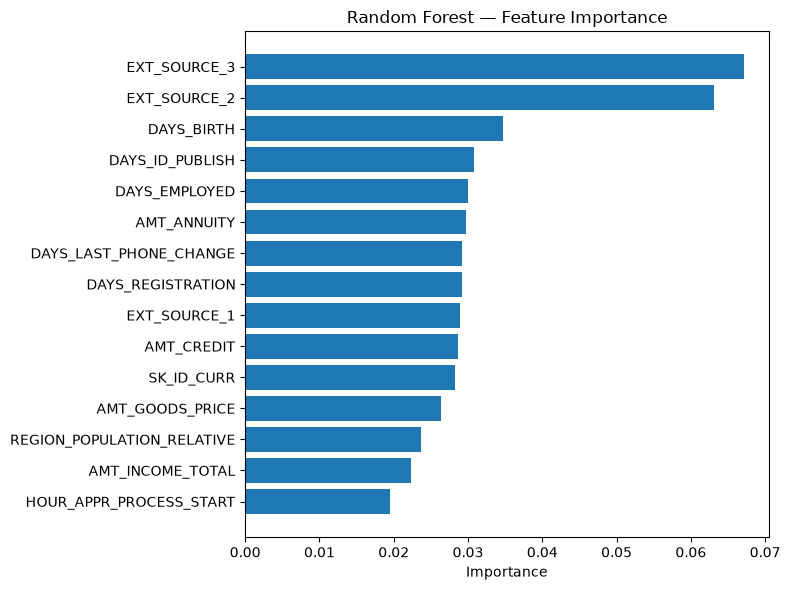

2026/09/06 13:16:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '615420678695431d840d13a5988a1e77', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19919, number of negative: 226089
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11629
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/06 13:16:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run calm-roo-234 at: http://localhost:5000/#/experiments/2/runs/615420678695431d840d13a5988a1e77
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 13:17:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8d661ea7d9b94494b6793d2189d368ea', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

🏃 View run enchanting-snake-461 at: http://localhost:5000/#/experiments/2/runs/881750f427da4b55a5fe2ccfce9fc7a4
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/09/06 13:19:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '544e3e2cb377429fa98516ef8a17ab27', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19767, number of negative: 226242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11638
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


2026/09/06 13:20:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run bold-seal-239 at: http://localhost:5000/#/experiments/2/runs/544e3e2cb377429fa98516ef8a17ab27
🧪 View experiment at: http://localhost:5000/#/experiments/2


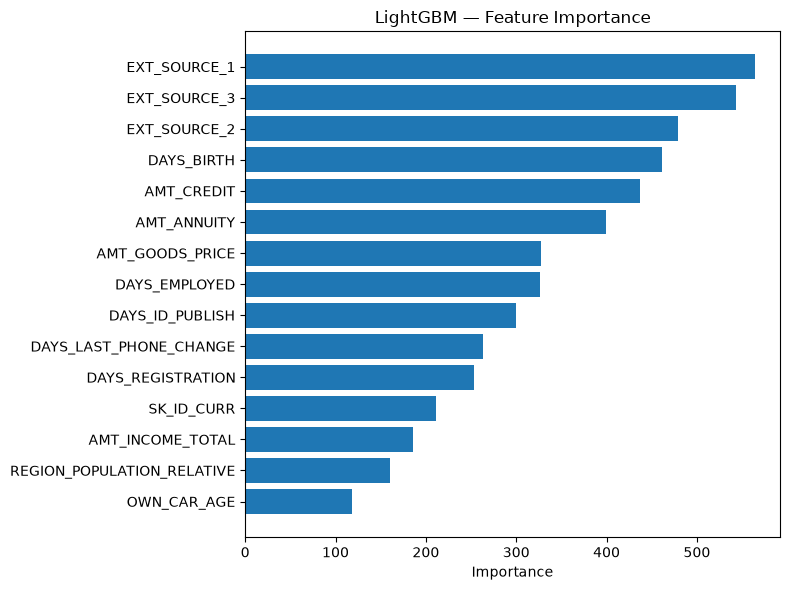

In [21]:
# FEATURE IMPORTANCE (RANDOM FOREST + LIGHTGBM)
def plot_feature_importances(importances, feature_names, title, top_n=15):
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1])
    plt.xlabel('Importance')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return fi_df

# Random Forest : ré-entraîné sur X_full/y_full pour être cohérent avec la comparaison ci-dessus
rf_full = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=50, n_jobs=-1)
rf_full.fit(X_full, y_full)
fi_rf = plot_feature_importances(rf_full.feature_importances_, X_full.columns, 'Random Forest — Feature Importance')

# LightGBM : réutilisation de la fonction model_lightgbm définie plus haut
_, fi_lgbm, _ = model_lightgbm(X_full, df_test[X_full.columns], y_full)
fi_lgbm_sorted = plot_feature_importances(fi_lgbm['importance'].values, fi_lgbm['feature'].values, 'LightGBM — Feature Importance')

## OPTIMISATION D'HYPERPARAMÈTRES (GRIDSEARCHCV / OPTUNA)

 Optimisation des hyperparamètres du meilleur modèle identifié dans la comparaison ci-dessus (à adapter selon le modèle). Exemple avec `GridSearchCV` sur LightGBM, scoré en ROC-AUC via validation croisée stratifiée.

In [22]:
import re
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# 1. Nettoyage préventif des noms de colonnes pour LightGBM
X_full.columns = [re.sub(r'[ \[\{\]\}\":,]', '_', str(col)) for col in X_full.columns]

# 2. Grille d'hyperparamètres
param_dist = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
}

# 3. Modèle de base (n_jobs=1 pour laisser RandomizedSearchCV gérer le multi-threading)
lgbm_base = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    subsample=0.8,
    n_jobs=1,
    random_state=50
)

# 4. Configuration de RandomizedSearchCV (15 combinaisons testées)
opti_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=50),
    n_jobs=-1,
    verbose=1,
    random_state=50
)

# 5. Lancement de l'optimisation
opti_search.fit(X_full, y_full)

# 6. Résultats
print('Meilleurs hyperparamètres :', opti_search.best_params_)
print(f'Meilleur ROC-AUC (CV) : {opti_search.best_score_:.4f}')

best_lgbm = opti_search.best_estimator_

2026/09/06 13:24:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '31f3ddf6f5c84be6a50ce5fc05470721', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.232297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11609
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


2026/09/06 13:31:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\nabil\Documents\OC\MLOPS\Projet1\Projet Code Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
2026/09/06 13:32:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information,

🏃 View run burly-squid-223 at: http://localhost:5000/#/experiments/2/runs/0a24150c0d6d4661ab89fb5fa63e699e
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run burly-slug-722 at: http://localhost:5000/#/experiments/2/runs/a7b3e5212ea44e5693fc86dc5c72ef75
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run classy-squirrel-406 at: http://localhost:5000/#/experiments/2/runs/f6abe05be60747c7ae4e50f489b75ac6
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run unique-asp-235 at: http://localhost:5000/#/experiments/2/runs/ec29ee7638294fd894c8c667d93e76e3
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run gaudy-dog-297 at: http://localhost:5000/#/experiments/2/runs/1df0408b414a47a5af92ae7a3110f9b4
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run languid-duck-3 at: http://localhost:5000/#/experiments/2/runs/31f3ddf6f5c84be6a50ce5fc05470721
🧪 View experiment at: http://localhost:5000/#/experiments/2

## FONCTION DE COÛT MÉTIER (FN > FP)
 Dans le contexte du scoring crédit, un **faux négatif** (accorder un crédit à un client qui va faire défaut) coûte bien plus cher qu'un **faux positif** (refuser un crédit à un bon client, qui ne coûte qu'un manque à gagner). On formalise ce déséquilibre par une fonction de coût métier.

In [23]:
# FONCTION DE COÛT MÉTIER (FN > FP)
from sklearn.metrics import confusion_matrix

# Coûts métier à ajuster selon le contexte réel (ordre de grandeur : un défaut non détecté coûte 10x
# plus cher qu'un refus abusif — ratio à faire valider avec le métier)
COUT_FAUX_NEGATIF = 10   # coût d'un défaut non détecté (crédit accordé, client en défaut)
COUT_FAUX_POSITIF = 1    # coût d'un refus abusif (crédit refusé, bon client)

def cout_metier(y_true, y_pred, cout_fn=COUT_FAUX_NEGATIF, cout_fp=COUT_FAUX_POSITIF):
    """Coût métier total : pondère les faux négatifs plus lourdement que les faux positifs."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cout_fn * fn + cout_fp * fp

# Exemple d'utilisation avec le seuil par défaut (0.5)
y_pred_default = (out_of_fold if 'out_of_fold' in dir() else None)  # à remplacer par les prédictions du modèle retenu
print('Fonction de coût métier définie : cout_metier(y_true, y_pred)')

Fonction de coût métier définie : cout_metier(y_true, y_pred)


## TEST DE PLUSIEURS SEUILS DE DÉCISION

Jusqu'ici, toutes les prédictions de classe utilisaient implicitement le seuil par défaut de 0.5. On teste ici plusieurs seuils de décision sur les probabilités prédites.

In [25]:
# TEST DE PLUSIEURS SEUILS DE DÉCISION
# Nécessite des probabilités de validation : on utilise ici y_val / proba du meilleur modèle
# (à adapter : remplacer best_lgbm et X_full/y_full par le modèle et le split réellement retenus)
from sklearn.model_selection import train_test_split as tts

X_tr_thr, X_val_thr, y_tr_thr, y_val_thr = tts(X_full, y_full, test_size=0.2, random_state=50, stratify=y_full)
best_lgbm.fit(X_tr_thr, y_tr_thr)
proba_val_thr = best_lgbm.predict_proba(X_val_thr)[:, 1]

seuils = np.arange(0.05, 0.95, 0.05)
resultats_seuils = []

for seuil in seuils:
    preds_seuil = (proba_val_thr >= seuil).astype(int)
    resultats_seuils.append({
        'seuil': round(seuil, 2),
        'precision': precision_score(y_val_thr, preds_seuil, zero_division=0),
        'recall': recall_score(y_val_thr, preds_seuil, zero_division=0),
        'f1': f1_score(y_val_thr, preds_seuil, zero_division=0),
        'f2': fbeta_score(y_val_thr, preds_seuil, beta=2, zero_division=0),
        'f3': fbeta_score(y_val_thr, preds_seuil, beta=3, zero_division=0),
        'cout_metier': cout_metier(y_val_thr, preds_seuil),
    })

seuils_df = pd.DataFrame(resultats_seuils)
print(seuils_df.to_string(index=False))

2026/09/06 14:24:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9802e6a53f5b4966901a48788656c792', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11691
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/06 14:26:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run handsome-deer-671 at: http://localhost:5000/#/experiments/2/runs/9802e6a53f5b4966901a48788656c792
🧪 View experiment at: http://localhost:5000/#/experiments/2
 seuil  precision   recall       f1       f2       f3  cout_metier
  0.05   0.080820 1.000000 0.149553 0.305377 0.467875        56468
  0.10   0.082259 0.998792 0.152000 0.309377 0.472421        55386
  0.15   0.086469 0.989124 0.159035 0.320331 0.483938        52424
  0.20   0.093346 0.967170 0.170260 0.336732 0.499542        48271
  0.25   0.102455 0.938167 0.184735 0.356531 0.516700        43876
  0.30   0.112819 0.897482 0.200441 0.375356 0.529329        40131
  0.35   0.124650 0.851561 0.217467 0.393090 0.537886        37061
  0.40   0.137084 0.796576 0.233913 0.405966 0.537832        34996
  0.45   0.151331 0.737362 0.251123 0.415532 0.531527        33571
  0.50   0.165385 0.667069 0.265055 0.415183 0.511814        33244
  0.55   0.182024 0.599194 0.279225 0.410866 0.487473        33269
  0.60   0.202373 0.522256 

## OPTIMISATION DU SEUIL SELON LE COÛT MÉTIER

Le seuil optimal est celui qui **minimise le coût métier** défini plus haut.

Seuil optimal (coût métier minimal) : 0.5
seuil              0.500000
precision          0.165385
recall             0.667069
f1                 0.265055
f2                 0.415183
f3                 0.511814
cout_metier    33244.000000
Name: 9, dtype: float64


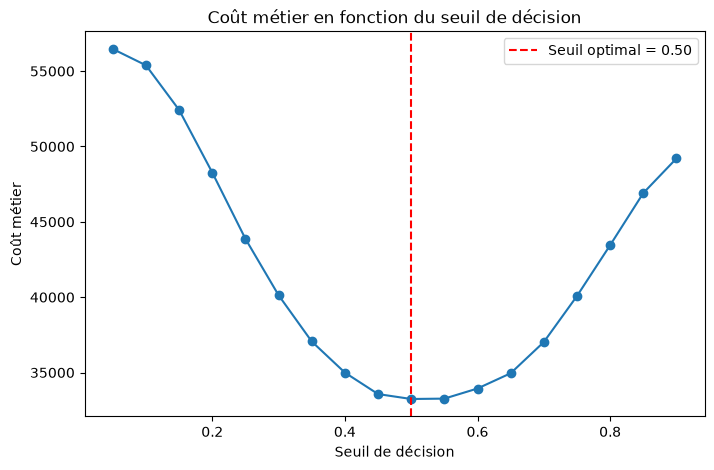

Seuil optimal (Score F2 maximal) : 0.45
seuil              0.450000
precision          0.151331
recall             0.737362
f1                 0.251123
f2                 0.415532
f3                 0.531527
cout_metier    33571.000000
Name: 8, dtype: float64


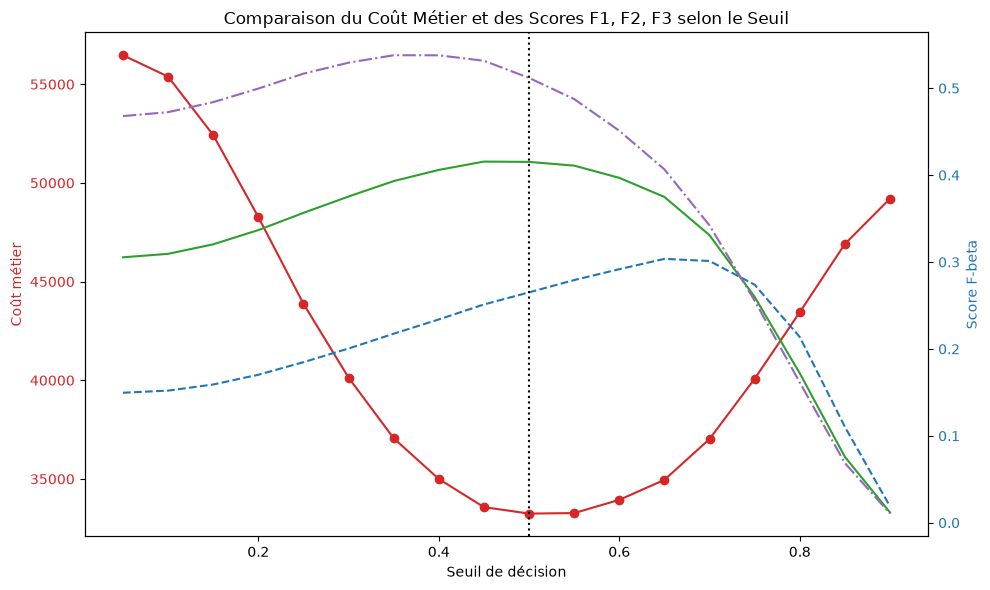

In [27]:
# OPTIMISATION DU SEUIL SELON LE COÛT MÉTIER
seuil_optimal_row = seuils_df.loc[seuils_df['cout_metier'].idxmin()]
print('Seuil optimal (coût métier minimal) :', seuil_optimal_row['seuil'])
print(seuil_optimal_row)

plt.figure(figsize=(8, 5))
plt.plot(seuils_df['seuil'], seuils_df['cout_metier'], marker='o')
plt.axvline(seuil_optimal_row['seuil'], color='red', linestyle='--',
            label=f"Seuil optimal = {seuil_optimal_row['seuil']:.2f}")
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier')
plt.title('Coût métier en fonction du seuil de décision')
plt.legend()
plt.show()

seuil_optimal = seuil_optimal_row['seuil']

# OPTIMISATION DU SEUIL SELON LE SCORE F2
seuil_f2_optimal_row = seuils_df.loc[seuils_df['f2'].idxmax()]
print('Seuil optimal (Score F2 maximal) :', seuil_f2_optimal_row['seuil'])
print(seuil_f2_optimal_row)

# Graphique combinant Coût Métier et F-scores
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe 1 : Coût Métier
ax1.plot(seuils_df['seuil'], seuils_df['cout_metier'], color='tab:red', marker='o', label='Coût Métier')
ax1.set_xlabel('Seuil de décision')
ax1.set_ylabel('Coût métier', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Axe 2 : Scores F1, F2, F3
ax2 = ax1.twinx()
ax2.plot(seuils_df['seuil'], seuils_df['f1'], color='tab:blue', linestyle='--', label='F1-score')
ax2.plot(seuils_df['seuil'], seuils_df['f2'], color='tab:green', linestyle='-', label='F2-score (Métier)')
ax2.plot(seuils_df['seuil'], seuils_df['f3'], color='tab:purple', linestyle='-.', label='F3-score')
ax2.set_ylabel('Score F-beta', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Ligne du seuil optimal selon le coût
plt.axvline(seuil_optimal_row['seuil'], color='black', linestyle=':', 
            label=f"Seuil coût min. = {seuil_optimal_row['seuil']:.2f}")

plt.title('Comparaison du Coût Métier et des Scores F1, F2, F3 selon le Seuil')
fig.tight_layout()
plt.show()

Voici l'explication détaillée de ce résultat d'évaluation de votre modèle.


 **Seuil d'appétence / Décision (0.50)**

* **Qu'est-ce que c'est ?** Par défaut, un modèle de classification prédit une probabilité entre 0 et 1. Le seuil (*threshold*) est la limite à partir de laquelle le modèle bascule la prédiction : si la probabilité estimée que le client soit en défaut est **$\ge 0.50$**, il est classé comme "à risque".
* **Pourquoi est-il "optimal" ?** Dans votre analyse, ce seuil de 0.50 est celui qui **minimise le coût financier total pour la banque**, en trouvant le meilleur compromis entre refuser des crédits à de bons clients et accorder des crédits à des clients insolvables.


## MLP — FONCTION D'ACTIVATION (NON APPLICABLE)

(Point non applicable ici : aucun modèle de type MLP (perceptron multicouche / réseau de neurones dense) n'est utilisé dans ce pipeline — seuls des modèles de type régression logistique et arbres (Random Forest, LightGBM) sont testés. Si un MLP devait être ajouté, il faudrait justifier le choix de la fonction d'activation des couches cachées